In [120]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
from neuralmonkey.classes.population_mult import extract_single_pa
from pythonlib.tools.plottools import savefig
from pythonlib.dataset.scripts.analy_manuscript_figures_FINAL import SAVEDIR_ALL
import os
from pythonlib.dataset.scripts.analy_manuscript_figures_FINAL import fig5_load_data
import numpy as np
import pickle
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [122]:
animal = 'Pancho'
date = 240516
morphset = 0

In [123]:
_, map_morphset_to_dfallpa, map_tcmorphset_to_idxmorph, list_morphset, map_tcmorphset_to_info = fig5_load_data(animal, date)


# This dataset holds only trials for this morphset, where morphset is a set of images morphing
# from one extreme (learned prim) to another extreme (another learned prim).

# A given day has multiple morphsets, each indexed by an integer
for ms, dfallpa in map_morphset_to_dfallpa.items():
    print("A morphset index on this day: ", ms)

# Otherwise, use dfallpa as usual
_, map_morphset_to_dfallpa, map_tcmorphset_to_idxmorph, list_morphset, map_tcmorphset_to_info = fig5_load_data(animal, date)

bregion = "PMv"

Running ..  M1
Running ..  PMv
Running ..  PMd
Running ..  dlPFC
Running ..  vlPFC
Running ..  FP
Running ..  SMA
Running ..  preSMA
Running ..  M1
Running ..  PMv
Running ..  PMd
Running ..  dlPFC
Running ..  vlPFC
Running ..  FP
Running ..  SMA
Running ..  preSMA
A morphset index on this day:  2
A morphset index on this day:  4
Running ..  M1
Running ..  PMv
Running ..  PMd
Running ..  dlPFC
Running ..  vlPFC
Running ..  FP
Running ..  SMA
Running ..  preSMA
Running ..  M1
Running ..  PMv
Running ..  PMd
Running ..  dlPFC
Running ..  vlPFC
Running ..  FP
Running ..  SMA
Running ..  preSMA


In [124]:
DFallpa = map_morphset_to_dfallpa[list(map_morphset_to_dfallpa.keys())[0]]

PA = extract_single_pa(DFallpa, bregion, None, "trial")

from neuralmonkey.analyses.decode_moment import train_decoder_helper, pipeline_train_test_scalar_score, pipeline_train_test_scalar_score_mult_train_dataset, test_decoder_helper, train_decoder_helper_extract_train_dataset
from neuralmonkey.scripts.analy_pig_decode_moment_syntaxTI import get_dataset_params
import os

SAVEDIR = "/tmp/psycho_decode"
os.makedirs(SAVEDIR, exist_ok=True)

# Pipeline to train and test
## So this is the code for training the decoder to learn reps of each morph? or each prim on either end?
include_null_data = True
n_min_per_var = 5

# Train params
# Train just on endpoints
event_train = "03_samp"
twind_train = (0.05, 0.9)
filterdict_train = {"idxmorph_assigned":["0|base1", "99|base2"]}
which_level_train = "trial"
var_train = "idxmorph_assigned" # The trained variable

# Test params
event_test = "03_samp"
filterdict_test = None
list_twind_test = [(0.6, 1.0)]
which_level_test = "trial"
var_test = "idxmorph_assigned"

# Subtrract baseline? from decoding score?
subtract_baseline=False
subtract_baseline_twind=None
# subtract_baseline_twind=(-0.45, -0.05)

# Helper to extract params
# event_train, twind_train, filterdict_train, _, which_level_train = get_dataset_params(train_dataset)
# event_test, _, filterdict_test, list_twind_test, which_level_test = get_dataset_params(test_dataset)

# Other general params
do_upsample_balance=True # Upsample data to fix imbalance?
PLOT = True
prune_labels_exist_in_train_and_test = False #
decoder_method_index = None # Use default
savedir = f"{SAVEDIR}/decoder_training-upsample={do_upsample_balance}/{bregion}"
os.makedirs(savedir, exist_ok=True)

dec_dir = f'/home/danhan/code/fixation_analyses/decoders/{animal}/{date}/{morphset}'
dec = f'{dec_dir}/decoder.pkl'
os.makedirs(dec_dir, exist_ok=True)
if os.path.exists(dec):
    with open(dec,'rb') as f:
        dfscores, Dc, PAtrain, PAtest = pickle.load(f)
else:
    ret = pipeline_train_test_scalar_score(DFallpa, bregion, 
                                        var_train, event_train, twind_train, filterdict_train,
                                        var_test, event_test, list_twind_test, filterdict_test,
                                        savedir, include_null_data=include_null_data,
                                        prune_labels_exist_in_train_and_test=prune_labels_exist_in_train_and_test, PLOT=PLOT,
                                        which_level_train=which_level_train, which_level_test=which_level_test, 
                                        n_min_per_var=n_min_per_var,
                                        subtract_baseline=subtract_baseline, subtract_baseline_twind=subtract_baseline_twind,
                                        do_upsample_balance=do_upsample_balance, allow_multiple_twind_test=True,
                                        classifier_version="logistic")
    with open(dec,'wb') as f:
        pickle.dump(ret,f)
    dfscores, Dc, PAtrain, PAtest = ret
dflab = PAtest.Xlabels['trials']

twind = (-0.4, 1.0)

PAprobs, probs_mat_all, times, labels = Dc.timeseries_score_wrapper(PAtest, twind)

In [125]:
def genStateDf(probs_mat_all,times,labels,dflab):
    prim0_dim = [i for i,e in enumerate(labels) if e == '0|base1'][0]
    prim99_dim = [i for i,e in enumerate(labels) if e == '99|base2'][0]
    null_dim =[i for i,e in enumerate(labels) if e == 'null'][0]
    rows = []


    def get_state_defs(b1,b2, high = 0.5, low = 0.5):
        return {
        1: (b1 > high) & (b2 < low),
        2: (b1 < low) & (b2 > high),
        3: (b1 < low) & (b2 < low),
        4: (b1 > high) & (b2 > high)
        #0: default/unlabeled
        }
    def get_samp_class(t1,t2):
        if t1 > 0 and t2 > 0:
            ret = 1 #1 if state fully in samp
        elif t1 < 0 and t2 < 0:
            ret = -1 #-1 is state during presamp
        else:
            ret = 0 #0 if state straddles samp on
        return ret
        

    
    for indtrial in range(probs_mat_all.shape[1]):
        probs = probs_mat_all[:,indtrial,:]
        b1 = probs[prim0_dim]
        b2 = probs[prim99_dim]
        state_defs = get_state_defs(b1,b2)
        states_trial = np.zeros(len(b1),dtype=int)
        for state_id,ind in state_defs.items():
            states_trial[ind] = state_id
        start = 0
        end = 0
        state_change_points = np.where(np.diff(states_trial) != 0)[0] + 1
        segments = np.split(np.arange(len(states_trial)), state_change_points)
        for seg in segments:
            start = seg[0]
            end = seg[-1]

            rows.append({
                'indtrial': indtrial,
                'state_id': states_trial[start],
                't_start': times[start],
                't_end': times[end],
                'dur': times[end] - times[start],
                'samp_onoff_class': get_samp_class(times[start], times[end]),
                'ambig_label': dflab.iloc[indtrial]['assigned_label'],
                'shape_drawn': dflab.iloc[indtrial]['assigned_base_simple'],
                'shape_name': dflab.iloc[indtrial]['idxmorph_assigned']
            })

    return pd.DataFrame(rows)
        


In [126]:
probs_mat_all.shape

(3, 184, 129)

In [127]:
df_states = genStateDf(probs_mat_all,times,labels,dflab)

In [128]:
min_dur = 0.2
df_post_samp = df_states[df_states['t_end'] > 0.1]
df_states_dur = df_post_samp[df_post_samp['dur'] > min_dur]
shape_order = ['base1', 'base2']

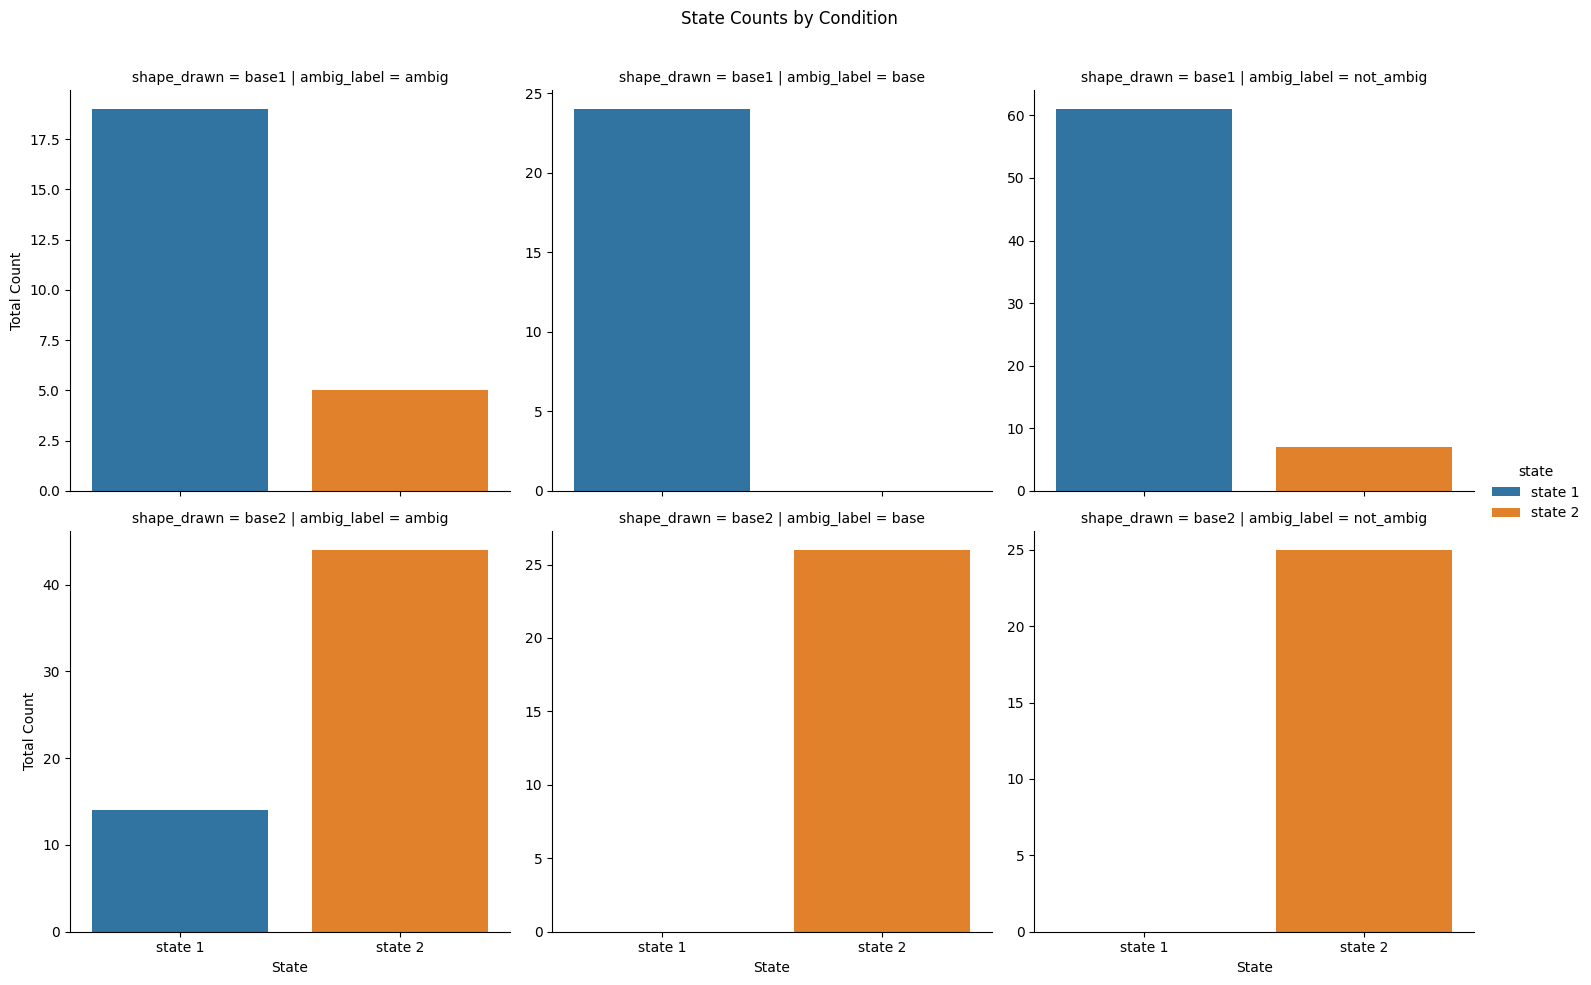

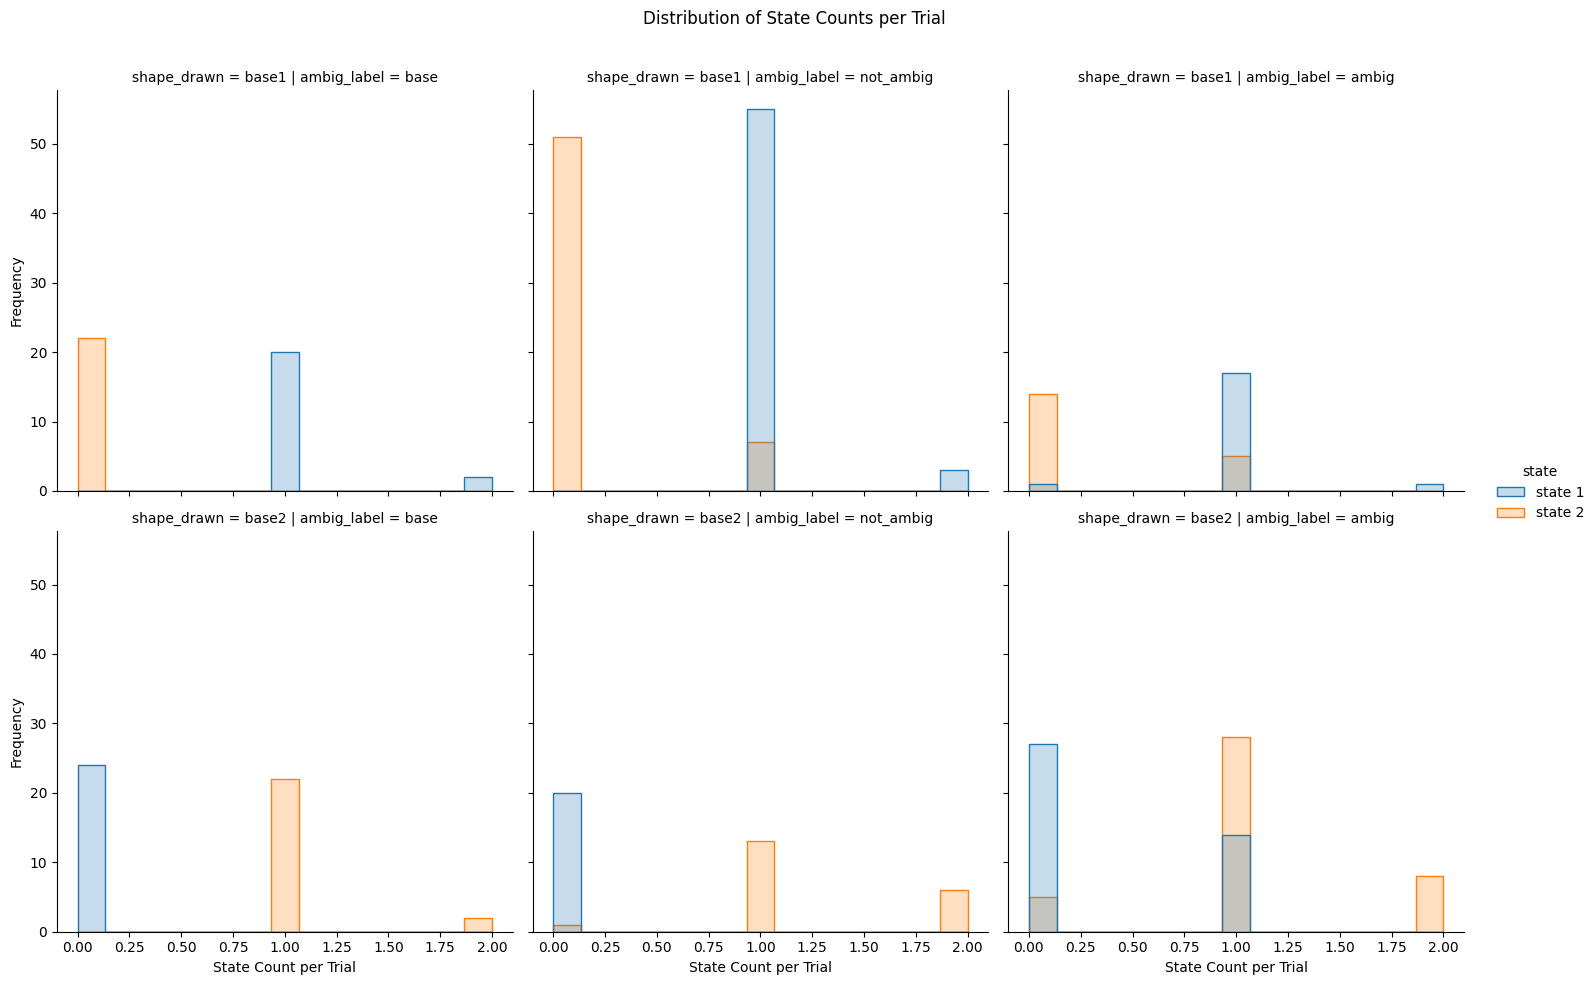

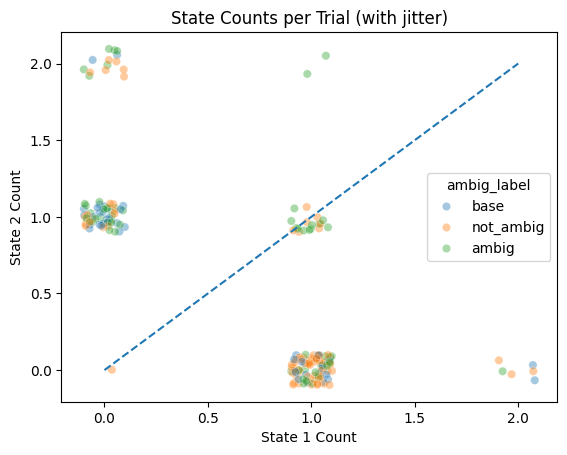

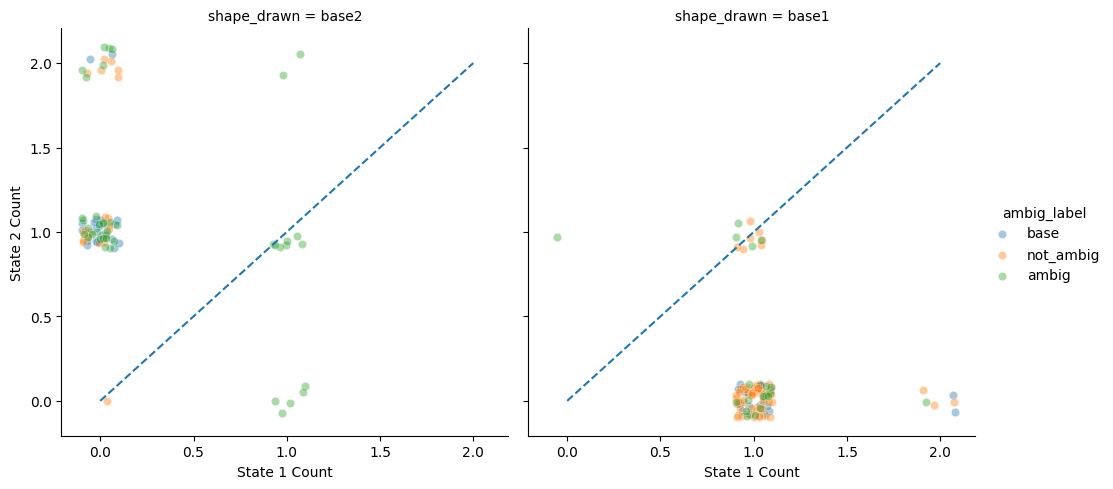

In [149]:
figs = plotStateCounts(df_states_dur,shape_order=shape_order)

In [ ]:
def plotStateCounts(df_states_dur, shape_order=['base1','base2'], jitter_strength=0.1):


    figs = []

    # -----------------------------
    # 1. Aggregate counts (global)
    # -----------------------------
    df_counts = (
        df_states_dur
        .groupby(['ambig_label', 'shape_drawn', 'state_id'])
        .size()
        .reset_index(name='count')
    )

    df_counts['state'] = df_counts['state_id'].map({
        1: 'state 1',
        2: 'state 2'
    })

    if shape_order is not None:
        df_counts['shape_drawn'] = pd.Categorical(
            df_counts['shape_drawn'],
            categories=shape_order,
            ordered=True
        )

    # --- Plot 1: Barplot ---
    g1 = sns.catplot(
        data=df_counts,
        x='state',
        y='count',
        hue='state',
        col='ambig_label',
        row='shape_drawn',
        kind='bar',
        sharey=False,
    )

    g1.set_axis_labels("State", "Total Count")
    g1.fig.subplots_adjust(top=0.9)
    g1.fig.suptitle("State Counts by Condition")

    figs.append(g1.fig)

    # -----------------------------
    # 2. Trial-level counts
    # -----------------------------
    df_trial_counts = (
        df_states_dur
        .groupby(['indtrial', 'ambig_label', 'shape_drawn', 'state_id'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename(columns={
            1: 'state 1',
            2: 'state 2'
        })
    )

    # Long format (for histogram)
    df_long = df_trial_counts.melt(
        id_vars=['indtrial', 'ambig_label', 'shape_drawn'],
        value_vars=['state 1', 'state 2'],
        var_name='state',
        value_name='count'
    )

    if shape_order is not None:
        df_long['shape_drawn'] = pd.Categorical(
            df_long['shape_drawn'],
            categories=shape_order,
            ordered=True
        )

    # --- Plot 2: Histogram ---
    g2 = sns.displot(
        data=df_long,
        x='count',
        hue='state',
        col='ambig_label',
        row='shape_drawn',
        kind='hist',
        bins=15,
        common_norm=False,
        element='step'
    )

    g2.set_axis_labels("State Count per Trial", "Frequency")
    g2.fig.subplots_adjust(top=0.9)
    g2.fig.suptitle("Distribution of State Counts per Trial")

    figs.append(g2.fig)

    # -----------------------------
    # 3. Scatter prep (wide + jitter)
    # -----------------------------
    counts_wide = df_trial_counts.copy()

    counts_wide['state1_jitter'] = (
        counts_wide['state 1'] +
        np.random.uniform(-jitter_strength, jitter_strength, size=len(counts_wide))
    )

    counts_wide['state2_jitter'] = (
        counts_wide['state 2'] +
        np.random.uniform(-jitter_strength, jitter_strength, size=len(counts_wide))
    )

    max_val = counts_wide[['state 1', 'state 2']].to_numpy().max()

    # --- Plot 3: Scatter (single) ---
    fig3, ax3 = plt.subplots()

    sns.scatterplot(
        data=counts_wide,
        x='state1_jitter',
        y='state2_jitter',
        hue='ambig_label',
        alpha=0.4,
        ax=ax3
    )

    ax3.set_xlabel('State 1 Count')
    ax3.set_ylabel('State 2 Count')
    ax3.set_title('State Counts per Trial (with jitter)')

    figs.append(fig3)

    # --- Plot 4: Scatter faceted by shape ---
    g4 = sns.FacetGrid(
        counts_wide,
        col='shape_drawn',
        hue='ambig_label',
        height=5,
        aspect=1
    )

    g4.map_dataframe(
        sns.scatterplot,
        x='state1_jitter',
        y='state2_jitter',
        alpha=0.4
    )

    g4.add_legend()

    figs.append(g4.fig)

    return figs